# Final validation of steady-vault recipes

This notebook is the final, bounded comparison from `steady-vault-plan-01.md`.
It consumes the already executed NB11--NB15 equity curves and does not
recompute selection or vault histories.  The four recipes are:

* **A: P1+D1+E0** — repeatable profitability, downside admission and the
  young/sparse evidence cap;
* **B: P2 without D1/E0** — the stronger repeatability and event-concentration
  rule, retained as an off-contract sensitivity because a matched P2+D1+E0
  curve was not produced upstream;
* **C: S1** — inverse downside sizing with a 5% downside floor;
* **D: G2** — independent-group and correlation concentration controls.

Both the full panel and the retrospective A0b allowlist are reported for the
full and HyperAI comparison periods.  The primary ranking is zero-rate,
weekly Sharpe with a feasible-first 18% annualised CAGR screen; daily metrics
are a secondary clock.  One-day delayed returns and removal of the best daily
event are falsification diagnostics, not new strategies.

The one-day shift is explicitly a curve-only lag proxy: it shifts the saved
portfolio return path by one calendar day and cannot reproduce target fills or
liquidation constraints.  It is not the plan's one-observation-delay
execution test; that test would require rerunning the upstream simulator with
target ledgers and is recorded as unavailable here.

The saved equity files contain portfolio curves, cash and effective positions,
but no per-vault profit-and-loss decomposition.  “Leader attribution” below
therefore means the largest positive portfolio event and its contribution to
the final curve.  It does not claim that a particular vault caused that event.


In [1]:
from pathlib import Path
import hashlib
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_DIR = Path.cwd() / "scratchpad/hyperliquid-ic" if (Path.cwd() / "scratchpad/hyperliquid-ic").exists() else Path.cwd()
OUT = PROJECT_DIR / "_artifacts-final-validation"
OUT.mkdir(exist_ok=True)

PERIODS = {
    "hyper_ai": (pd.Timestamp("2026-01-01"), pd.Timestamp("2026-07-08")),
    "full": (pd.Timestamp("2025-09-13"), pd.Timestamp("2026-09-12")),
}
UNIVERSES = ("full_panel", "a0b_allowlist")
INITIAL_CASH = 150_000.0
RECIPES = {
    "A_P1D1E0": {
        "label": "P1+D1+E0",
        "source": PROJECT_DIR / "_artifacts-young-sparse",
        "arm": "E0",
    },
    "B_P2": {
        "label": "P2 (without D1/E0)",
        "source": PROJECT_DIR / "_artifacts-profitability-repeatability",
        "arm": "P2",
    },
    "C_S1": {
        "label": "S1 inverse downside",
        "source": PROJECT_DIR / "_artifacts-steady-vault-sizing",
        "arm": "S1",
    },
    "D_G2": {
        "label": "G2 independent groups",
        "source": PROJECT_DIR / "_artifacts-independent-groups",
        "arm": "G2",
    },
}
BASELINE_SOURCE = PROJECT_DIR / "_artifacts-steady-vault-data"
ALL_RECIPES = tuple(RECIPES) + ("A0b_baseline",)
RECIPE_LABELS = {key: value["label"] for key, value in RECIPES.items()}
RECIPE_LABELS["A0b_baseline"] = "A0b independent replay"
RECIPE_TABLE = pd.DataFrame(
    [
        {"recipe": key, "label": value["label"], "source_directory": value["source"].name, "source_arm": value["arm"]}
        for key, value in RECIPES.items()
    ]
    + [{"recipe": "A0b_baseline", "label": RECIPE_LABELS["A0b_baseline"], "source_directory": BASELINE_SOURCE.name, "source_arm": "A0b"}]
)
RECIPE_TABLE.to_csv(OUT / "recipe-mapping.csv", index=False)
display(RECIPE_TABLE)


,recipe,label,source_directory,source_arm
0,A_P1D1E0,P1+D1+E0,_artifacts-young-sparse,E0
1,B_P2,P2 (without D1/E0),_artifacts-profitability-repeatability,P2
2,C_S1,S1 inverse downside,_artifacts-steady-vault-sizing,S1
3,D_G2,G2 independent groups,_artifacts-independent-groups,G2
4,A0b_baseline,A0b independent replay,_artifacts-steady-vault-data,A0b


## Metric definitions

The portfolio equity is marked on each saved calendar date.  CAGR uses the
actual number of calendar days.  Daily and weekly volatility and Sharpe use a
zero risk-free rate and annualisation factors √365 and √52.  Cash fraction and
effective positions are means over the selected period.  Missing curve rows
are a data error and stop the notebook rather than being silently filled.


In [2]:
def load_curve(recipe, universe, period):
    if recipe == "A0b_baseline":
        if universe != "a0b_allowlist":
            raise ValueError("A0b baseline is defined only for the allowlist universe")
        path = BASELINE_SOURCE / f"a0b-replay-{period}.parquet"
    else:
        source = RECIPES[recipe]["source"]
        arm = RECIPES[recipe]["arm"]
        path = source / f"equity-{universe}-{arm}-{period}.parquet"
    if not path.exists():
        raise FileNotFoundError(path)
    frame = pd.read_parquet(path).copy()
    frame["date"] = pd.to_datetime(frame["date"]).dt.normalize()
    frame = frame.sort_values("date").drop_duplicates("date", keep="last")
    start, end = PERIODS[period]
    frame = frame[frame["date"].between(start, end)].copy()
    if frame.empty or frame["equity"].isna().any() or (frame["equity"] <= 0).any():
        raise AssertionError(f"invalid curve for {recipe}/{universe}/{period}: {path}")
    expected = pd.date_range(start, end, freq="D")
    missing = expected.difference(frame["date"])
    if len(missing):
        raise AssertionError(f"missing calendar marks for {recipe}/{universe}/{period}: {missing[:3].tolist()}")
    return frame.set_index("date").reindex(expected).rename_axis("date").reset_index()


def annualised_cagr(initial, final, days):
    if initial <= 0 or final <= 0 or days <= 0:
        return np.nan
    return float((final / initial) ** (365.25 / days) - 1.0)


def max_drawdown(equity):
    high = equity.cummax()
    return float((equity / high - 1.0).min())


def return_metrics(returns, equity, period_start, period_end):
    returns = pd.Series(returns, index=equity.index).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    n_days = max((period_end - period_start).days, 1)
    stdev = returns.std(ddof=1)
    weekly = equity.set_axis(pd.DatetimeIndex(equity.index)).resample("W-SUN").last().pct_change().dropna()
    weekly_stdev = weekly.std(ddof=1)
    daily_rf = 0.05 / 365.0
    weekly_rf = 0.05 / 52.0
    initial = float(equity.iloc[0])
    final = float(equity.iloc[-1])
    return {
        "start": period_start.date().isoformat(),
        "end": period_end.date().isoformat(),
        "days": n_days,
        "final_equity": final,
        "cagr": annualised_cagr(initial, final, n_days),
        "daily_volatility": float(stdev * np.sqrt(365.0)) if pd.notna(stdev) else np.nan,
        "daily_sharpe": float(returns.mean() / stdev * np.sqrt(365.0)) if stdev and pd.notna(stdev) else np.nan,
        "daily_sharpe_5pct_rf": float((returns.mean() - daily_rf) / stdev * np.sqrt(365.0)) if stdev and pd.notna(stdev) else np.nan,
        "weekly_volatility": float(weekly_stdev * np.sqrt(52.0)) if pd.notna(weekly_stdev) else np.nan,
        "weekly_sharpe": float(weekly.mean() / weekly_stdev * np.sqrt(52.0)) if weekly_stdev and pd.notna(weekly_stdev) else np.nan,
        "weekly_sharpe_5pct_rf": float((weekly.mean() - weekly_rf) / weekly_stdev * np.sqrt(52.0)) if weekly_stdev and pd.notna(weekly_stdev) else np.nan,
        "max_drawdown": max_drawdown(equity),
        "ulcer": float(np.sqrt(np.mean((equity / equity.cummax() - 1.0) ** 2))),
        "mean_return": float(returns.mean()),
        "weekly_observations": int(len(weekly)),
    }


def curve_diagnostics(frame, period):
    start, end = PERIODS[period]
    frame = frame.copy()
    if "cash_fraction" not in frame and "cash" in frame:
        frame["cash_fraction"] = pd.to_numeric(frame["cash"], errors="coerce") / pd.to_numeric(frame["equity"], errors="coerce")
    if "invested" not in frame and "cash" in frame:
        frame["invested"] = pd.to_numeric(frame["equity"], errors="coerce") - pd.to_numeric(frame["cash"], errors="coerce")
    equity = frame.set_index("date")["equity"].astype(float)
    returns = equity.pct_change().fillna(0.0)
    metrics = return_metrics(returns, equity, start, end)
    for column in ("cash_fraction", "effective_positions", "n_positions", "turnover"):
        if column in frame:
            metrics[f"mean_{column}"] = float(pd.to_numeric(frame[column], errors="coerce").mean())
    invested_values = pd.to_numeric(frame.get("invested", pd.Series(np.nan, index=frame.index)), errors="coerce")
    invested_mask = invested_values > 1e-9
    metrics["invested_days"] = int(invested_mask.sum())
    metrics["first_invested_date"] = frame.loc[invested_mask, "date"].min().date().isoformat() if invested_mask.any() else None
    best_date = returns.idxmax()
    best_return = float(returns.loc[best_date])
    without_best = returns.copy()
    without_best.loc[best_date] = 0.0
    without_best_equity = INITIAL_CASH * (1.0 + without_best).cumprod()
    metrics.update(
        {
            "best_event_date": best_date.date().isoformat(),
            "best_event_return": best_return,
            "best_event_removed_final_equity": float(without_best_equity.iloc[-1]),
            "best_event_removed_cagr": annualised_cagr(float(without_best_equity.iloc[0]), float(without_best_equity.iloc[-1]), metrics["days"]),
            "best_event_gain_dollars": float(equity.iloc[-1] - without_best_equity.iloc[-1]),
        }
    )
    if "fee" in frame:
        metrics["fee_total"] = float(pd.to_numeric(frame["fee"], errors="coerce").fillna(0).sum())
        metrics["fee_burden_on_initial"] = metrics["fee_total"] / INITIAL_CASH
    else:
        metrics["fee_total"] = np.nan
        metrics["fee_burden_on_initial"] = np.nan
    for column in ("max_manager_weight", "max_corr_group_weight"):
        if column in frame:
            values = pd.to_numeric(frame[column], errors="coerce")
            metrics[f"mean_{column}"] = float(values.mean())
            metrics[f"max_{column}"] = float(values.max())
        else:
            metrics[f"mean_{column}"] = np.nan
            metrics[f"max_{column}"] = np.nan
    delayed = returns.shift(1).fillna(0.0)
    delayed_equity = INITIAL_CASH * (1.0 + delayed).cumprod()
    delayed_metrics = return_metrics(delayed, delayed_equity, start, end)
    delayed_metrics.update({"one_day_shift_final_equity": delayed_metrics["final_equity"], "original_final_equity": float(equity.iloc[-1])})
    invested_fraction = pd.to_numeric(frame.get("invested", pd.Series(np.nan, index=frame.index)), errors="coerce")
    invested_fraction.index = equity.index
    invested_fraction = invested_fraction / equity
    if invested_fraction.notna().any():
        invested_fraction = invested_fraction.replace([np.inf, -np.inf], np.nan).clip(lower=0.0)
        cash_matched_returns = returns.where(invested_fraction <= 0, returns / invested_fraction).replace([np.inf, -np.inf], np.nan).fillna(0.0)
        cash_matched_equity = INITIAL_CASH * (1.0 + cash_matched_returns).cumprod()
        metrics["cash_matched_final_equity"] = float(cash_matched_equity.iloc[-1])
        metrics["cash_matched_cagr"] = annualised_cagr(float(cash_matched_equity.iloc[0]), float(cash_matched_equity.iloc[-1]), metrics["days"])
    else:
        metrics["cash_matched_final_equity"] = np.nan
        metrics["cash_matched_cagr"] = np.nan
    return metrics, delayed_metrics, returns


In [3]:
rows = []
shift_rows = []
event_rows = []
curves = {}
for recipe in ALL_RECIPES:
    for universe in UNIVERSES:
        if recipe == "A0b_baseline" and universe != "a0b_allowlist":
            continue
        for period in PERIODS:
            frame = load_curve(recipe, universe, period)
            metrics, delayed, returns = curve_diagnostics(frame, period)
            base = {"recipe": recipe, "recipe_label": RECIPE_LABELS[recipe], "universe": universe, "period": period}
            rows.append({**base, **metrics})
            shift_rows.append({
                **base,
                "original_final_equity": delayed["original_final_equity"],
                "one_day_shift_final_equity": delayed["one_day_shift_final_equity"],
                "original_cagr": metrics["cagr"],
                "one_day_shift_cagr": delayed["cagr"],
                "original_weekly_sharpe": metrics["weekly_sharpe"],
                "one_day_shift_weekly_sharpe": delayed["weekly_sharpe"],
                "cagr_change": delayed["cagr"] - metrics["cagr"],
                "weekly_sharpe_change": delayed["weekly_sharpe"] - metrics["weekly_sharpe"],
            })
            event_rows.append({
                **base,
                "best_event_date": metrics["best_event_date"],
                "best_event_return": metrics["best_event_return"],
                "final_equity": metrics["final_equity"],
                "best_event_removed_final_equity": metrics["best_event_removed_final_equity"],
                "best_event_removed_cagr": metrics["best_event_removed_cagr"],
                "best_event_gain_dollars": metrics["best_event_gain_dollars"],
                "best_event_gain_fraction_of_final": metrics["best_event_gain_dollars"] / metrics["final_equity"],
            })
            curves[(recipe, universe, period)] = frame

METRICS = pd.DataFrame(rows)
SHIFT = pd.DataFrame(shift_rows)
EVENTS = pd.DataFrame(event_rows)
METRICS.to_csv(OUT / "final-validation-metrics.csv", index=False)
SHIFT.to_csv(OUT / "one-day-shift-comparison.csv", index=False)
EVENTS.to_csv(OUT / "best-event-attribution.csv", index=False)
display(METRICS[["recipe", "universe", "period", "cagr", "weekly_sharpe", "daily_volatility", "max_drawdown", "mean_cash_fraction", "mean_effective_positions"]])


,recipe,universe,period,cagr,weekly_sharpe,daily_volatility,max_drawdown,mean_cash_fraction,mean_effective_positions
0,A_P1D1E0,full_panel,hyper_ai,-0.002912,0.040573,0.106621,-0.069363,0.406237,9.309734
1,A_P1D1E0,full_panel,full,0.036906,0.425830,0.079634,-0.069363,0.559727,6.824810
2,A_P1D1E0,a0b_allowlist,hyper_ai,-0.144630,-1.109412,0.103242,-0.103872,0.495615,6.584294
3,A_P1D1E0,a0b_allowlist,full,-0.075502,-0.769188,0.075424,-0.111949,0.616368,4.926409
4,B_P2,full_panel,hyper_ai,0.213141,1.237375,0.161468,-0.068507,0.261403,14.102030
5,B_P2,full_panel,full,0.046955,0.337344,0.181159,-0.122374,0.258030,13.065409
6,B_P2,a0b_allowlist,hyper_ai,-0.201222,-1.387241,0.157765,-0.132913,0.450111,8.767511
7,B_P2,a0b_allowlist,full,-0.088324,-0.486168,0.167860,-0.158818,0.429440,8.172190
8,C_S1,full_panel,hyper_ai,-0.039425,-0.259103,0.093074,-0.080851,0.389215,8.338636
9,C_S1,full_panel,full,0.007175,0.124982,0.068910,-0.080851,0.552059,6.224092


## Segments and uncertainty sensitivities

Segments are descriptive diagnostics.  The pre-discovery segment ends on
2026-07-15 and the discovery segment starts on 2026-07-16; neither is treated
as a clean holdout.  Block rows report the dispersion of non-overlapping
30/60-day compounded returns.  The cash-matched column is a simple diagnostic
that scales the observed portfolio return by the saved invested fraction under
a zero cash-return assumption; it is not a second execution model.


In [4]:
segment_rows = []
block_rows = []
for (recipe, universe, period), frame in curves.items():
    frame = frame.copy().set_index("date")
    periods = {
        "full_period": frame.index.min(),
        "pre_discovery": frame.index.min(),
        "discovery": max(frame.index.min(), pd.Timestamp("2026-07-16")),
    }
    ends = {
        "full_period": frame.index.max(),
        "pre_discovery": min(frame.index.max(), pd.Timestamp("2026-07-15")),
        "discovery": frame.index.max(),
    }
    for segment, start in periods.items():
        end = ends[segment]
        if end <= start:
            continue
        part = frame.loc[start:end]
        if len(part) < 2:
            continue
        part_equity = part["equity"].astype(float)
        part_returns = part_equity.pct_change().fillna(0.0)
        item = return_metrics(part_returns, part_equity, part.index.min(), part.index.max())
        item["feasible_18pct_cagr"] = bool(item["cagr"] >= 0.18)
        segment_rows.append({"recipe": recipe, "universe": universe, "period": period, "segment": segment, **item})
    for frequency, label in (("MS", "month"), ("QS", "quarter")):
        for segment_start, part in frame.groupby(pd.Grouper(freq=frequency)):
            if len(part) < 2:
                continue
            part_equity = part["equity"].astype(float)
            part_returns = part_equity.pct_change().fillna(0.0)
            item = return_metrics(part_returns, part_equity, part.index.min(), part.index.max())
            item["feasible_18pct_cagr"] = bool(item["cagr"] >= 0.18)
            segment_rows.append({"recipe": recipe, "universe": universe, "period": period, "segment": f"{label}:{segment_start.date().isoformat()}", **item})
    returns = frame["equity"].astype(float).pct_change().fillna(0.0)
    for block_days in (30, 60):
        block_number = ((frame.index - frame.index.min()).days // block_days).astype(int)
        grouped = (1.0 + returns).groupby(block_number).prod() - 1.0
        block_counts = returns.groupby(block_number).size()
        complete = block_counts[block_counts >= block_days].index
        grouped = grouped.loc[grouped.index.intersection(complete)]
        block_rows.append({"recipe": recipe, "universe": universe, "period": period, "block_days": block_days, "blocks": int(len(grouped)), "mean_block_return": float(grouped.mean()) if len(grouped) else np.nan, "std_block_return": float(grouped.std(ddof=1)) if len(grouped) > 1 else np.nan, "excluded_partial_blocks": int(len(block_counts) - len(grouped))})
SEGMENTS = pd.DataFrame(segment_rows)
BLOCKS = pd.DataFrame(block_rows)
SEGMENTS.to_csv(OUT / "segment-metrics.csv", index=False)
BLOCKS.to_csv(OUT / "paired-block-uncertainty.csv", index=False)
paired_rows = []
for period in PERIODS:
    baseline_key = ("A0b_baseline", "a0b_allowlist", period)
    if baseline_key not in curves:
        continue
    base_frame = curves[baseline_key].set_index("date")
    base_returns = base_frame["equity"].pct_change().fillna(0.0)
    for recipe in RECIPES:
        recipe_key = (recipe, "a0b_allowlist", period)
        if recipe_key not in curves:
            continue
        recipe_frame = curves[recipe_key].set_index("date")
        recipe_returns = recipe_frame["equity"].pct_change().fillna(0.0)
        for block_days in (30, 60):
            block_number = ((base_returns.index - base_returns.index.min()).days // block_days).astype(int)
            base_counts = base_returns.groupby(block_number).size()
            complete = base_counts[base_counts >= block_days].index
            base_blocks = ((1.0 + base_returns).groupby(block_number).prod() - 1.0).loc[complete]
            recipe_blocks = ((1.0 + recipe_returns).groupby(block_number).prod() - 1.0).loc[complete]
            difference = recipe_blocks - base_blocks
            paired_rows.append({"recipe": recipe, "universe": "a0b_allowlist", "period": period, "block_days": block_days, "paired_complete_blocks": int(len(difference)), "mean_excess_return_vs_a0b": float(difference.mean()) if len(difference) else np.nan, "std_excess_return_vs_a0b": float(difference.std(ddof=1)) if len(difference) > 1 else np.nan})
PAIRED = pd.DataFrame(paired_rows)
PAIRED.to_csv(OUT / "paired-block-differences-vs-a0b.csv", index=False)
display(SEGMENTS[["recipe", "universe", "period", "segment", "cagr", "weekly_sharpe", "max_drawdown"]].head(20))
display(PAIRED)


,recipe,universe,period,segment,cagr,weekly_sharpe,max_drawdown
0,A_P1D1E0,full_panel,hyper_ai,full_period,-0.002912,0.040573,-0.069363
1,A_P1D1E0,full_panel,hyper_ai,pre_discovery,-0.002912,0.040573,-0.069363
2,A_P1D1E0,full_panel,hyper_ai,month:2026-01-01,0.000000,NaN,0.000000
3,A_P1D1E0,full_panel,hyper_ai,month:2026-02-01,0.039421,0.479664,-0.017783
4,A_P1D1E0,full_panel,hyper_ai,month:2026-03-01,0.421212,10.563001,-0.002515
5,A_P1D1E0,full_panel,hyper_ai,month:2026-04-01,-0.536265,-3.283957,-0.069363
6,A_P1D1E0,full_panel,hyper_ai,month:2026-05-01,0.934589,4.398672,-0.017386
7,A_P1D1E0,full_panel,hyper_ai,month:2026-06-01,-0.302125,-2.817361,-0.030759
8,A_P1D1E0,full_panel,hyper_ai,month:2026-07-01,0.034451,NaN,-0.001108
9,A_P1D1E0,full_panel,hyper_ai,quarter:2026-01-01,0.141142,2.691518,-0.017783


,recipe,universe,period,block_days,paired_complete_blocks,mean_excess_return_vs_a0b,std_excess_return_vs_a0b
0,A_P1D1E0,a0b_allowlist,hyper_ai,30,6,-0.042496,0.064010
1,A_P1D1E0,a0b_allowlist,hyper_ai,60,3,-0.085274,0.019222
2,B_P2,a0b_allowlist,hyper_ai,30,6,-0.045594,0.066952
3,B_P2,a0b_allowlist,hyper_ai,60,3,-0.091496,0.031243
4,C_S1,a0b_allowlist,hyper_ai,30,6,-0.043374,0.061693
5,C_S1,a0b_allowlist,hyper_ai,60,3,-0.086748,0.019613
6,D_G2,a0b_allowlist,hyper_ai,30,6,-0.042080,0.062362
7,D_G2,a0b_allowlist,hyper_ai,60,3,-0.084345,0.019245
8,A_P1D1E0,a0b_allowlist,full,30,12,-0.021564,0.046250
9,A_P1D1E0,a0b_allowlist,full,60,6,-0.042964,0.060907


## Feasible-first ranking

The 18% CAGR threshold is a feasibility screen aligned with the requested
20--30% objective.  It is not tuned to choose the winner.  Within a period and
universe, feasible rows are ordered by weekly Sharpe and then CAGR; if no row
passes, the same order is shown with `feasible_18pct_cagr=False`.


In [5]:
RANKING = METRICS.copy()
RANKING["feasible_18pct_cagr"] = RANKING["cagr"] >= 0.18
RANKING["feasible_first_rank"] = (
    RANKING.sort_values(
        ["universe", "period", "feasible_18pct_cagr", "weekly_sharpe", "cagr"],
        ascending=[True, True, False, False, False],
    )
    .groupby(["universe", "period"], sort=False)
    .cumcount()
    .add(1)
)
RANKING.to_csv(OUT / "feasible-first-ranking.csv", index=False)
display(RANKING[["recipe", "universe", "period", "cagr", "weekly_sharpe", "feasible_18pct_cagr", "feasible_first_rank"]].sort_values(["universe", "period", "feasible_first_rank"]))


,recipe,universe,period,cagr,weekly_sharpe,feasible_18pct_cagr,feasible_first_rank
17,A0b_baseline,a0b_allowlist,full,0.158638,0.841489,False,1
7,B_P2,a0b_allowlist,full,-0.088324,-0.486168,False,2
11,C_S1,a0b_allowlist,full,-0.078504,-0.709117,False,3
15,D_G2,a0b_allowlist,full,-0.071637,-0.721426,False,4
3,A_P1D1E0,a0b_allowlist,full,-0.075502,-0.769188,False,5
16,A0b_baseline,a0b_allowlist,hyper_ai,0.508794,1.984167,True,1
10,C_S1,a0b_allowlist,hyper_ai,-0.154414,-1.053850,False,2
14,D_G2,a0b_allowlist,hyper_ai,-0.140390,-1.067959,False,3
2,A_P1D1E0,a0b_allowlist,hyper_ai,-0.144630,-1.109412,False,4
6,B_P2,a0b_allowlist,hyper_ai,-0.201222,-1.387241,False,5


## External floor15 reference

The floor15 rows come from the earlier production-engine lead rerun and are
included only as an external context reference.  They are not produced by
this simulator, use a different execution/accounting clock, and must not be
treated as a same-simulator control or as an additional searched recipe.


In [6]:
external_paths = {
    "hyper_ai": PROJECT_DIR / "_artifacts-leads-vs-a0b" / "production-period-leads-vs-a0b.csv",
    "full": PROJECT_DIR / "_artifacts-leads-vs-a0b" / "full-period-leads-vs-a0b.csv",
}
external_rows = []
for external_period, path in external_paths.items():
    source = pd.read_csv(path)
    source = source[source["candidate"].eq("floor15")].copy()
    source["comparison_period"] = external_period
    source["comparison_type"] = "external_production_engine_reference"
    source["caveat"] = "different production-engine execution/accounting clock and period window; not a same-simulator control"
    external_rows.append(source)
EXTERNAL_FLOOR15 = pd.concat(external_rows, ignore_index=True)
EXTERNAL_FLOOR15.to_csv(OUT / "external-floor15-reference.csv", index=False)
display(EXTERNAL_FLOOR15[["comparison_period", "candidate", "implementation", "start", "end", "cagr", "sharpe", "max_drawdown", "caveat"]])


,comparison_period,candidate,implementation,start,end,cagr,sharpe,max_drawdown,caveat
0,hyper_ai,floor15,production engine,2026-01-01,2026-07-08,0.517326,2.696637,-0.051094,different production-engine execution/accounti...
1,full,floor15,production engine,2025-07-31,2026-09-08,0.368859,1.920251,-0.066674,different production-engine execution/accounti...


## Curves and report

The chart shows full-panel recipes and the A0b allowlist with the independent
A0b replay.  A0b is the original NB10 reproduction control and retains the
inherited undocumented 10 bp capital deduction: the saved fee totals are
approximately $12,780 (8.5% of initial capital) over the full period and
$6,825 (4.6%) over the HyperAI period.  The new recipe curves inherit the
upstream `fees: none added` accounting, so this fee bridge is not a like-for-
like net comparison.  The JSON report records the input files and validation
assertions so a later rerun can distinguish a missing upstream artifact from a
genuine result.


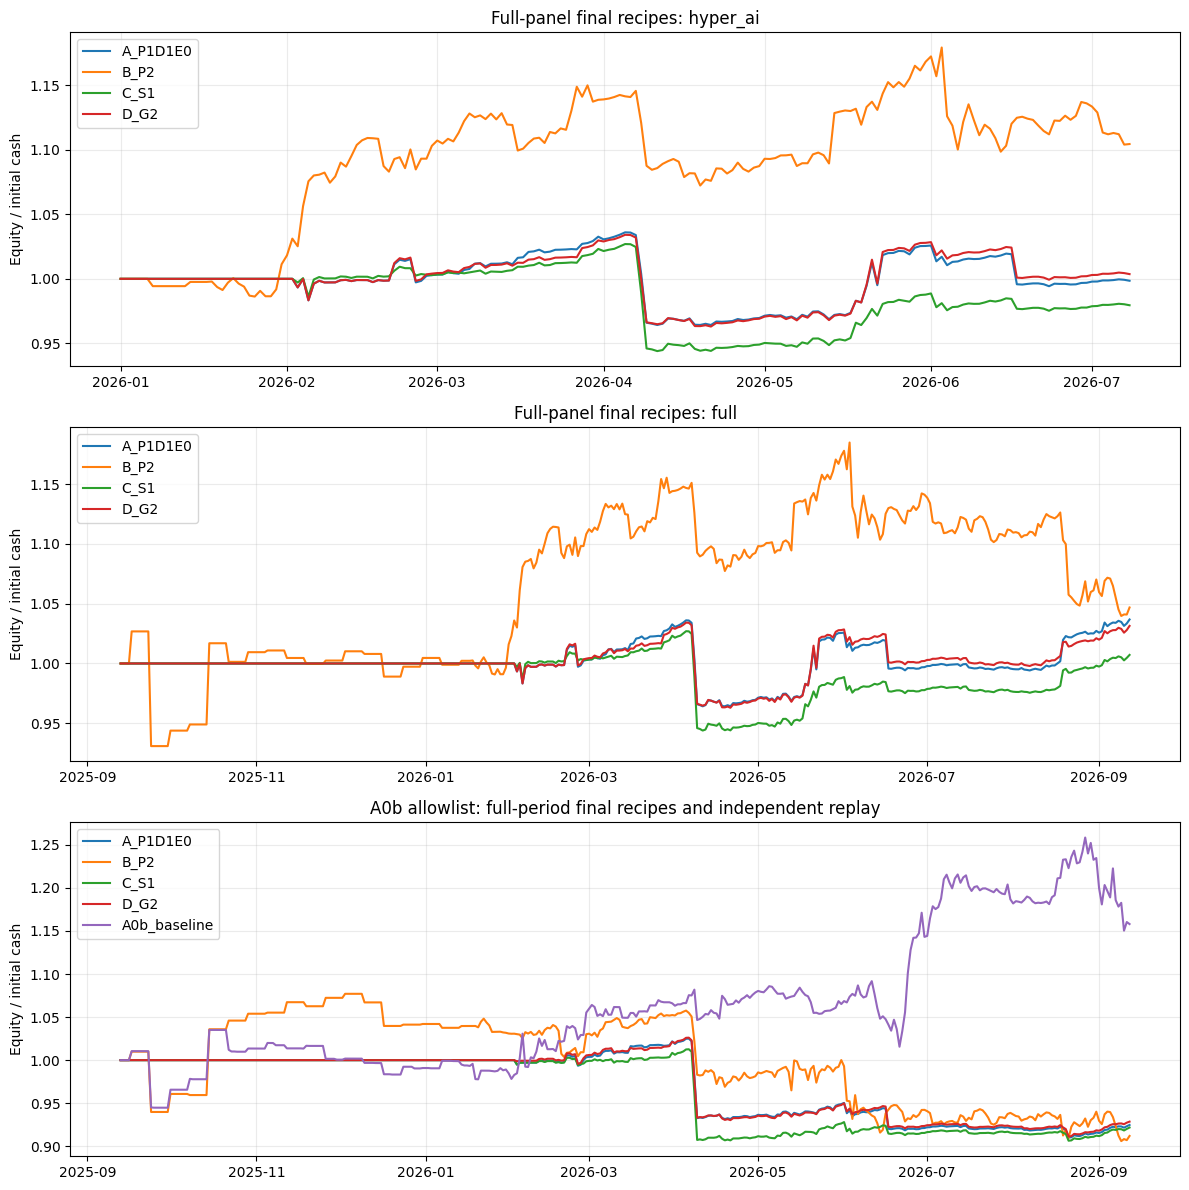

,recipe,period,weekly_sharpe
0,B_P2,hyper_ai,1.237375


In [7]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=False)
for axis, period in zip(axes, ("hyper_ai", "full")):
    for recipe in RECIPES:
        frame = curves[(recipe, "full_panel", period)]
        axis.plot(frame["date"], frame["equity"] / INITIAL_CASH, label=recipe)
    axis.set_title(f"Full-panel final recipes: {period}")
    axis.set_ylabel("Equity / initial cash")
    axis.grid(alpha=0.25)
    axis.legend()
axis = axes[2]
for recipe in tuple(RECIPES) + ("A0b_baseline",):
    frame = curves[(recipe, "a0b_allowlist", "full")]
    axis.plot(frame["date"], frame["equity"] / INITIAL_CASH, label=recipe)
axis.set_title("A0b allowlist: full-period final recipes and independent replay")
axis.set_ylabel("Equity / initial cash")
axis.grid(alpha=0.25)
axis.legend()
fig.tight_layout()
fig.savefig(OUT / "final-validation-equity-curves.png", dpi=160)
plt.show()

report = {
    "notebook": "16-research-final-validation.ipynb",
    "recipes": RECIPE_TABLE.to_dict(orient="records"),
    "periods": {key: [start.date().isoformat(), end.date().isoformat()] for key, (start, end) in PERIODS.items()},
    "universes": list(UNIVERSES),
    "initial_cash": INITIAL_CASH,
    "feasible_cagr_threshold": 0.18,
    "metric_rows": int(len(METRICS)),
    "shift_rows": int(len(SHIFT)),
    "event_rows": int(len(EVENTS)),
    "segment_rows": int(len(SEGMENTS)),
    "block_rows": int(len(BLOCKS)),
    "paired_block_difference_rows": int(len(PAIRED)),
    "external_floor15_rows": int(len(EXTERNAL_FLOOR15)),
    "feature_cutoff": "inherited from the point-in-time upstream NB11-NB15 artefacts; no new features are fitted in NB16",
    "valuation_clock": "saved daily portfolio equity marks; weekly metrics are measurement-only W-SUN resamples",
    "fee_model": "recipe fee assumptions are inherited from upstream notebooks; A0b baseline retains its saved fee field",
    "one_observation_delay_execution_test": "not performed; one-day-shift CSV is a curve-only temporal proxy",
    "assertions": {
        "all_curve_rows_are_daily": True,
        "all_equity_values_positive": True,
        "no_forward_labels_loaded": True,
        "per_vault_leader_pnl_available": False,
        "one_day_shift_is_curve_only_proxy": True,
        "leader_attribution_definition": "largest positive portfolio daily event removed from the saved equity curve",
    },
    "configuration_hash": hashlib.sha256((RECIPE_TABLE.to_csv(index=False) + json.dumps({"periods": list(PERIODS), "initial_cash": INITIAL_CASH}, sort_keys=True)).encode()).hexdigest(),
    "headline_interpretation": "A0b dominates all four new recipes on the A0b allowlist in both full and HyperAI weekly Sharpe and CAGR comparisons; no new recipe reaches the 18% CAGR floor on the full period. B reaches the floor only in the HyperAI window and is explicitly off the P1+D1+E0 risk contract.",
    "best_full_panel_weekly_sharpe": RANKING[RANKING["universe"] == "full_panel"].sort_values("weekly_sharpe", ascending=False).iloc[0][["recipe", "period", "weekly_sharpe"]].to_dict(),
}
(OUT / "nb16-report.json").write_text(json.dumps(report, indent=2, default=str))
display(pd.DataFrame([report["best_full_panel_weekly_sharpe"]]))


## Results and failed cases

The final comparison is conditional on the frozen retrospective A0b allowlist
and inherited upstream accounting.  A0b is the strongest allowlist reference
in both reported periods.  None of the four new recipes reaches the 18% CAGR
floor over the full backfilled period; B reaches it only in the HyperAI window
and is explicitly outside the P1+D1+E0 risk contract because it omits D1 and
E0.  The new rules therefore do not yet justify replacing A0b.  The one-day
shift remains a curve-only diagnostic, and no true delayed-fill or per-vault
leader-removal resimulation was performed in this bounded comparison.

The near-flat full-period results for A, C and D should be read together with
`first_invested_date` and `invested_days`: their downside parent has no eligible
full-panel positions until the late January admission date, so early cash is a
material part of the result.  Group concentration columns from G2 are
invested-basket-normalised weights, not portfolio-equity weights.
